In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cmap import Colormap

In [4]:
DATA_PATH = "/Volumes/VPB_external/Docs/UIUC/Beckman/Visualization_Workshop/data/Shruti/"

In [5]:

tsne = pd.read_csv(DATA_PATH + "metabolite_tsne/met_tsne.csv", index_col=0)
tsne.head()

,X,Y,smiles,tag
0,58.345024,-14.672801,CCC(=O)C(=O)O,common
1,52.882366,30.848186,O=c1ccn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]1,common
2,54.901207,35.162457,Nc1ccn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)n1,common
3,49.205032,-13.716556,CC(C)C(=O)C(=O)O,common
4,41.634018,-16.911266,CC(CO)C(=O)O,common


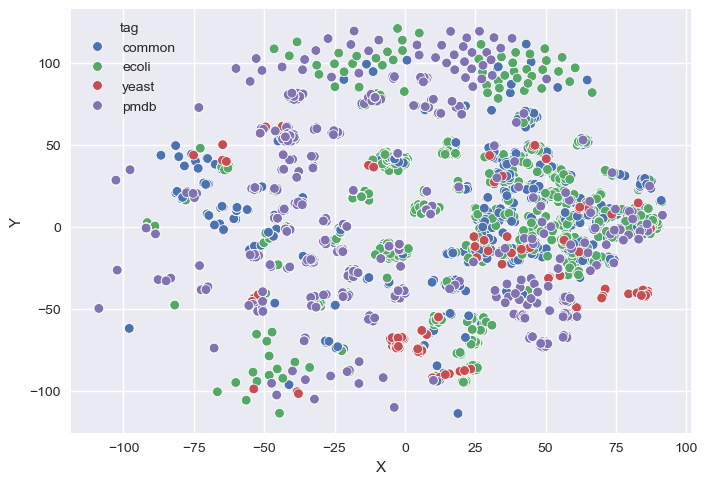

In [6]:
with plt.style.context("seaborn-v0_8"):
    sns.scatterplot(data=tsne, x="X", y="Y", hue="tag")
    plt.show()

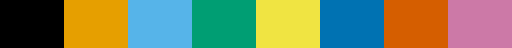

In [7]:
tags = tsne['tag'].unique()
LEGEND_LABELS = {"common": "Common", "ecoli": "E. coli", "yeast": "P. Aeruginosa", "pmdb":"S. cerevisiae"}
palette = Colormap("okabeito:okabeito")
palette

In [8]:
my_markers = {'ecoli': 'o', 'pmdb': 's', 'common': '^', 'yeast': 'D'}
my_palette = {
    'common': palette(1),  # amber
    'ecoli':  palette(2),  # blue
    'pmdb':   palette(7),  # pink/magenta
    'yeast':  palette(3),  # teal green
}

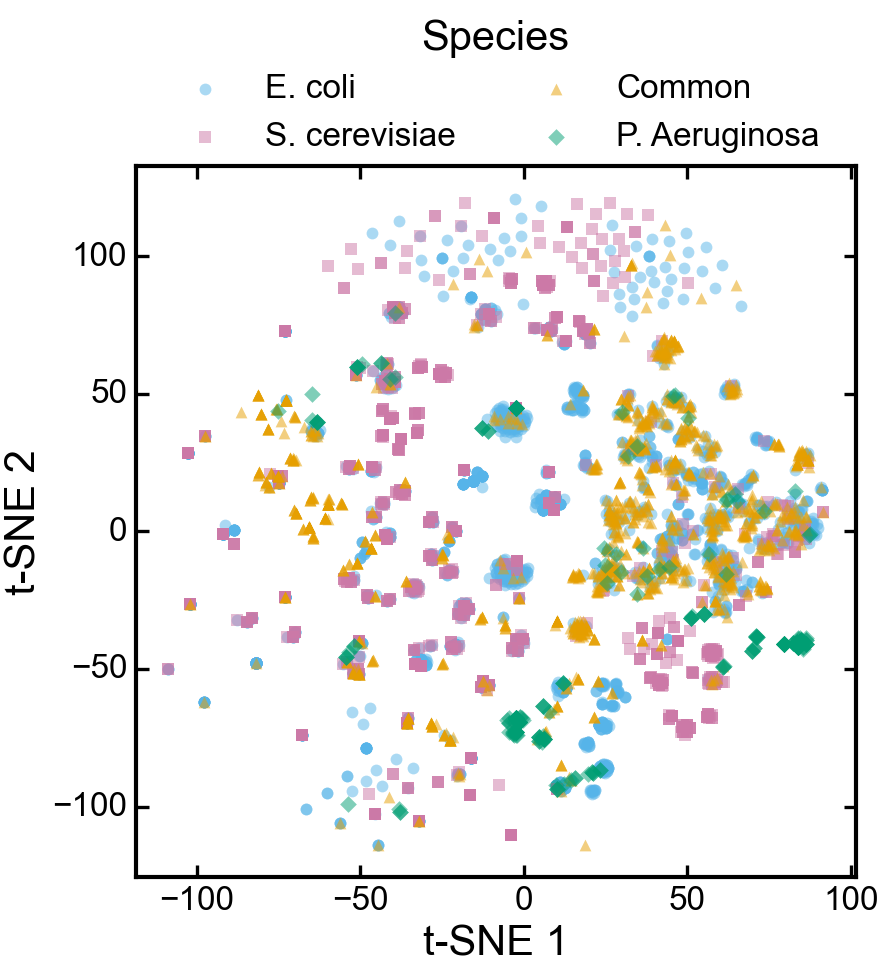

In [9]:
# To prevent style bleed-over from previous figures, use the matplotlib style context manager
# so that your custom style only applies within this plotting block:

with plt.style.context("../src/style_files/achemso.mplstyle"):

    # Determine tag order by frequency in the dataset (most frequent first)
    tag_order = tsne['tag'].value_counts().index.tolist()

    fig, ax = plt.subplots(figsize=(3,3))

    for tag in tag_order:
        subset = tsne[tsne["tag"] == tag]
        sns.scatterplot(
            data=subset,
            x="X",
            y="Y",
            c=[my_palette[tag]],
            marker=my_markers[tag],
            label=LEGEND_LABELS.get(tag, tag),
            s=8,
            edgecolor="white",
            linewidth=0,
            alpha=0.5,
        )
        # sns.kdeplot(data=subset, x='X', y='Y', 
        #         color=my_palette[tag], levels=3, linewidths=1.2, ax=ax)

    # Match legend labels to this auto-derived tag_order
    handles, _ = ax.get_legend_handles_labels()
    legend_labels = [LEGEND_LABELS.get(t, t) for t in tag_order]

    ax.legend(
        handles=handles,
        labels=legend_labels,
        title="Species",
        fontsize=8,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=2,
    )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.show()



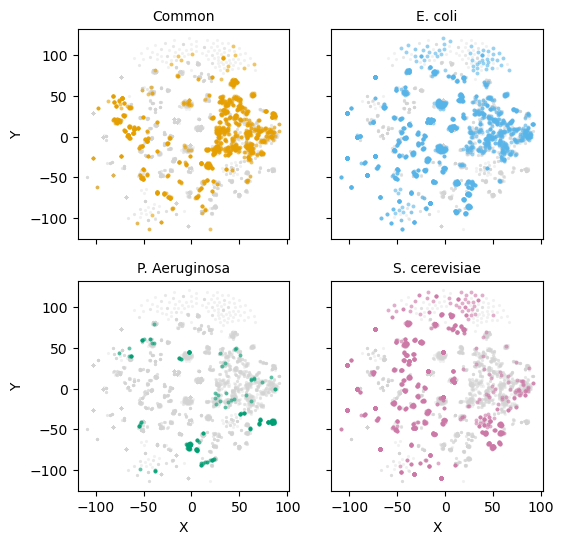

In [10]:
fig, axes = plt.subplots(2,2,figsize=(6,6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, tag, label in zip(axes, tags, LEGEND_LABELS.values()    ):
    
    # Background: all other points in light gray
    background = tsne[tsne['tag'] != tag]
    sns.scatterplot(background, x='X', y='Y', 
               s=5, color='lightgray', alpha=0.3, linewidth=0, ax=ax)
    
    # Foreground: this species in color
    subset = tsne[tsne['tag'] == tag]
    sns.scatterplot(subset, x='X', y='Y', 
               s=8, color=my_palette[tag], alpha=0.6, linewidth=0, ax=ax)
    
    ax.set_title(label, fontsize=10)

plt.show()


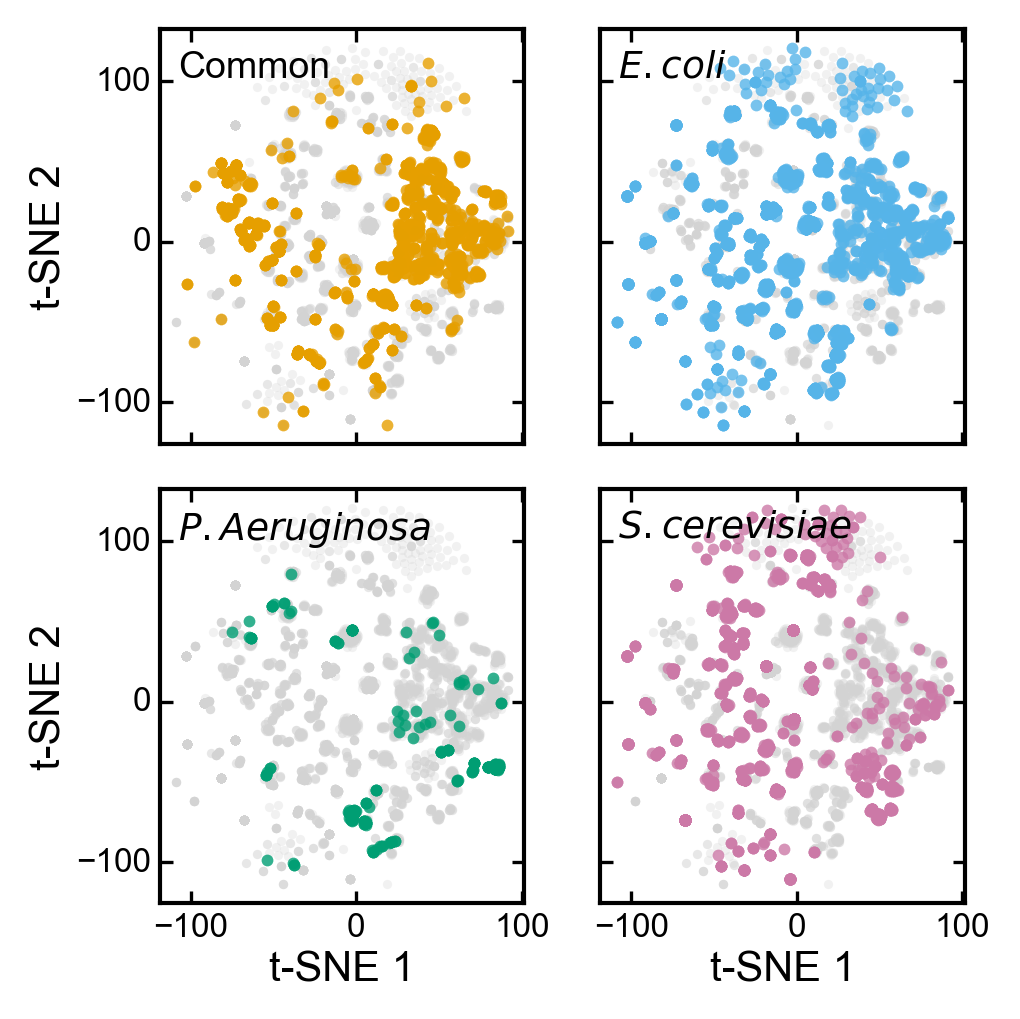

In [11]:

with plt.style.context("../src/style_files/achemso.mplstyle"):
    fig, axes = plt.subplots(2,2,figsize=(3.5,3.5), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, tag, label in zip(axes, tags, LEGEND_LABELS.values()    ):
        
        # Background: all other points in light gray
        background = tsne[tsne['tag'] != tag]
        sns.scatterplot(background, x='X', y='Y', 
                s=5, color='lightgray', alpha=0.3, linewidth=0, ax=ax)
        
        # Foreground: this species in color
        subset = tsne[tsne['tag'] == tag]
        sns.scatterplot(subset, x='X', y='Y', 
                s=8, color=my_palette[tag], alpha=0.8, linewidth=0, ax=ax)
        
        if label.lower() == 'common':
            ax.text(0.05, 0.95, label, fontsize=9, ha='left', va='top', transform=ax.transAxes)
        else:
            ax.text(0.05, 0.95, fr"$\it{{{label}}}$", fontsize=9, ha='left', va='top', transform=ax.transAxes)
    
    # Since axes share x and y, only set labels on the left and bottom plots
    # Set x labels only once for the bottom row
    for i in [2, 3]:
        axes[i].set_xlabel("t-SNE 1")
    # Set y labels only once for the left column
    for i in [0, 2]:
        axes[i].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()
